# Cost vs. accuracy — SWE-bench Verified (n=500) and Terminal-Bench 2.1 (n=89)

GLM-5.2 and Kimi-K3 generation cost on the two final result bundles:

- `results/swe-bench-verified/2026-08-08-aggregated-500`
- `results/terminal-bench2.1/20260807-aggregated-89`

Claude Opus 5 is excluded throughout: it was only ever run on the n=150 SWE-bench pool, which now
lives in the deprecated `2026-07-regraded` bundle, and it has no Terminal-Bench run.

It produces:

1. the actual recorded cost in the logs, with coverage, as an audit table;
2. the SWE-bench Verified cost/accuracy graph;
3. a paired per-task cost comparison with bootstrap confidence intervals;
4. a Terminal-Bench 2.1 cost/accuracy graph;
5. a combined graph with both benchmarks in one pane; and
6. a routing graph adding the solved-first, then-cheapest router to both benchmarks.

## One cost baseline

**Every cost in every figure is estimated from recorded token counts at published rates — for both
models, on both benchmarks.** Nothing is read from a recorded cost field.

This is necessary because the two models log cost very differently. GLM-5.2 records a cost on only 56
of its 525 SWE-bench attempts and 5 of its 101 Terminal-Bench attempts, totalling under $2; Kimi-K3
records one on nearly all of its attempts. Comparing a token-priced GLM-5.2 against a log-priced
Kimi-K3 would compare two different things. The recorded values are reported on their own below, and
where Kimi-K3 has both, the token estimate lands within 1% of its logged cost.

Prices per million tokens, checked 2026-08-05 against
[FriendliAI Model APIs pricing](https://friendli.ai/pricing):

| | uncached input | cached input | output |
|---|---:|---:|---:|
| GLM-5.2 | $1.40 | $0.26 | $4.40 |
| Kimi-K3 | $3.00 | $0.30 | $15.00 |

These are estimates at published rates, not historical invoices.

**Cost basis.** Every figure counts *all* generation attempts, retries included, over the fixed
benchmark denominator (500 or 89). Retries are real spend: GLM-5.2 took 525 attempts to cover the 500
SWE-bench tasks and 101 to cover the 89 Terminal-Bench tasks. Costing only the graded attempt would
understate both models.

Token accounting: `total_prompt_tokens` (and Terminal-Bench's `input_tokens`) includes cached input,
so uncached input is prompt minus cached. Reported reasoning tokens are not an additional billable
category; they are charged once at the output rate, via completion tokens.

Caveat in the recorded data: reasoning tokens are meant to be a subset of completion tokens, but 4 of
GLM-5.2's 525 SWE-bench attempts report slightly more reasoning than completion. Pricing uses
completion tokens, so cost is unaffected; the count surfaces as
`attempts_reasoning_over_completion` below and `visible_output_tokens` is floored at zero.

In [18]:
# Make the notebook runnable from a standard Python kernel.
import importlib.util
import shutil
import subprocess
import sys

required = {
    'matplotlib': 'matplotlib>=3.9',
    'pandas': 'pandas>=2.2',
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    print(f'Installing missing packages into {sys.executable}: {", ".join(missing)}')
    if uv := shutil.which('uv'):
        subprocess.check_call([uv, 'pip', 'install', '--python', sys.executable, *missing])
    else:
        if importlib.util.find_spec('pip') is None:
            subprocess.check_call([sys.executable, '-m', 'ensurepip', '--upgrade'])
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('Notebook dependencies are already available in this kernel.')

Notebook dependencies are already available in this kernel.


In [19]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

REPO = Path.cwd()
if not (REPO / 'results').exists():
    REPO = REPO.parent
SWE = REPO / 'results/swe-bench-verified/2026-08-08-aggregated-500'
TB = REPO / 'results/terminal-bench2.1/20260807-aggregated-89'
# Routing selections were computed separately; this notebook consumes them rather than re-deriving.
ROUTING_TASKS = REPO / 'notebooks/tmp/graphs/fig7_routing_glm_5_2_vs_kimi_k3_tasks.csv'
GRAPHS = REPO / 'notebooks/tmp/graphs'
for path in (SWE, TB, ROUTING_TASKS):
    assert path.exists(), f'Not found: {path}'
GRAPHS.mkdir(parents=True, exist_ok=True)

SWE_TASKS, TB_TASKS = 500, 89

# Published prices per million tokens. Both models are costed this way, from token counts only.
GLM_RATES_PER_MILLION = {'uncached_input': 1.40, 'cached_input': 0.26, 'output': 4.40}
KIMI_RATES_PER_MILLION = {'uncached_input': 3.00, 'cached_input': 0.30, 'output': 15.00}

MODELS = {
    'GLM-5.2 xhigh': {
        'swe': 'glm-5.2/xhigh_n500', 'tb': 'glm-5.2-xhigh', 'routing_key': 'GLM-5.2',
        'color': '#4c78a8', 'rates': GLM_RATES_PER_MILLION,
    },
    'Kimi-K3 max': {
        'swe': 'kimi-k3/max_n500', 'tb': 'kimi-k3-max', 'routing_key': 'Kimi-K3',
        'color': '#eb6834', 'rates': KIMI_RATES_PER_MILLION,
    },
}
ROUTING = {'label': 'Routing', 'color': '#00a950'}


def token_cost(uncached, cached, output, rates):
    """Cost at published rates. The single pricing function behind every figure in this notebook."""
    return (uncached * rates['uncached_input']
            + cached * rates['cached_input']
            + output * rates['output']) / 1_000_000

## Load and validate all SWE-bench trajectories

The 500-task bundle mixes two harnesses. The original 150 tasks carry a legacy trial directory with
`agent/trajectory.json`, whose `final_metrics` is a trajectory-level rollup of per-call usage. The
350-task complement carries a single mini-swe-agent `<instance_id>.traj.json`, where usage sits on
each message under `extra.response.usage`. Both are read here, and every attempt directory counts.

Missing reasoning or cost fields stay explicit through coverage counts rather than being zero-filled
silently.

In [20]:
def attempt_dirs(label):
    """Every generation attempt for a model, including retries, in instance order."""
    return sorted((SWE / 'results' / MODELS[label]['swe'] / 'generation').glob('*/attempt-*'))


def legacy_attempt(path):
    """Token totals from a legacy trial's final_metrics rollup."""
    metrics = json.loads(path.read_text())['final_metrics']
    extra = metrics.get('extra') or {}
    return {
        'prompt_tokens': int(metrics.get('total_prompt_tokens', 0) or 0),
        'cached_tokens': int(metrics.get('total_cached_tokens', 0) or 0),
        'completion_tokens': int(metrics.get('total_completion_tokens', 0) or 0),
        'reasoning_tokens': int(extra.get('total_reasoning_tokens', 0) or 0),
        'recorded_cost_usd': metrics.get('total_cost_usd'),
        'steps': int(metrics.get('total_steps', 0) or 0),
        'harness': 'legacy-trial',
    }


def native_attempt(paths):
    """Token totals summed from a mini-swe-agent trajectory's per-message usage."""
    totals = dict.fromkeys(
        ('prompt_tokens', 'cached_tokens', 'completion_tokens', 'reasoning_tokens', 'steps'), 0)
    recorded = None
    for path in paths:
        trajectory = json.loads(path.read_text())
        for message in trajectory.get('messages', []):
            response = message.get('extra', {}).get('response')
            usage = response.get('usage') if isinstance(response, dict) else None
            if not isinstance(usage, dict):
                continue
            prompt_details = usage.get('prompt_tokens_details') or {}
            completion_details = usage.get('completion_tokens_details') or {}
            totals['steps'] += 1
            totals['prompt_tokens'] += int(usage.get('prompt_tokens', usage.get('input_tokens', 0)) or 0)
            totals['completion_tokens'] += int(usage.get('completion_tokens', usage.get('output_tokens', 0)) or 0)
            totals['cached_tokens'] += int(
                (prompt_details.get('cached_tokens') if isinstance(prompt_details, dict) else 0)
                or usage.get('cache_read_input_tokens', 0) or 0)
            totals['reasoning_tokens'] += int(
                (completion_details.get('reasoning_tokens') if isinstance(completion_details, dict) else 0) or 0)
        instance_cost = (trajectory.get('info') or {}).get('model_stats', {}).get('instance_cost')
        if instance_cost:
            recorded = (recorded or 0.0) + float(instance_cost)
    return {**totals, 'recorded_cost_usd': recorded, 'harness': 'mini-swe-agent'}


def aggregate_attempts(label):
    rows = []
    for attempt in attempt_dirs(label):
        legacy = attempt / 'agent/trajectory.json'
        usage = legacy_attempt(legacy) if legacy.exists() else native_attempt(sorted(attempt.glob('*.traj.json')))
        rows.append({'instance_id': attempt.parent.name, 'attempt': attempt.name, **usage})
    frame = pd.DataFrame(rows)
    assert frame.instance_id.nunique() <= SWE_TASKS
    assert (frame.cached_tokens <= frame.prompt_tokens).all()
    # A few mini-swe-agent attempts report more reasoning tokens than completion tokens. Reasoning is
    # not billed separately, so cost is unaffected; count the records instead of asserting an
    # invariant the recorded usage does not hold.
    frame['reasoning_over_completion'] = frame.reasoning_tokens > frame.completion_tokens
    return frame


swe_attempts = {label: aggregate_attempts(label) for label in MODELS}
usage = pd.DataFrame({
    label: {
        'tasks_with_trajectory': frame.instance_id.nunique(),
        'attempts': len(frame),
        'prompt_tokens': int(frame.prompt_tokens.sum()),
        'cached_tokens': int(frame.cached_tokens.sum()),
        'uncached_tokens': int((frame.prompt_tokens - frame.cached_tokens).sum()),
        'completion_tokens': int(frame.completion_tokens.sum()),
        'reasoning_tokens': int(frame.reasoning_tokens.sum()),
        'visible_output_tokens': int((frame.completion_tokens - frame.reasoning_tokens).clip(lower=0).sum()),
        'attempts_reasoning_over_completion': int(frame.reasoning_over_completion.sum()),
        'recorded_cost_usd': float(frame.recorded_cost_usd.fillna(0).sum()),
        'cost_records': int(frame.recorded_cost_usd.notna().sum()),
        'steps': int(frame.steps.sum()),
    }
    for label, frame in swe_attempts.items()
}).T
usage

,tasks_with_trajectory,attempts,prompt_tokens,cached_tokens,uncached_tokens,completion_tokens,reasoning_tokens,visible_output_tokens,attempts_reasoning_over_completion,recorded_cost_usd,cost_records,steps
GLM-5.2 xhigh,499.0,525.0,942631996.0,925639104.0,16992892.0,12963249.0,9800518.0,3190669.0,4.0,1.544959,56.0,27804.0
Kimi-K3 max,500.0,518.0,470776494.0,427750249.0,43026245.0,8634791.0,5109713.0,3525078.0,0.0,383.765910,514.0,19338.0


## Price both models from tokens

Both models are priced with `token_cost` at their own published rates, over every attempt. The
recorded cost columns above are carried for audit only and are not used in any figure — see the
recorded-cost table below for how little GLM-5.2 actually logs.

The denominator is the full 500 either way. GLM-5.2 has a trajectory for 499 of them —
`sphinx-doc__sphinx-7454` produced no trajectory — so its per-task mean spreads the same spend over
one extra task rather than dropping it.

In [21]:
swe_cost_components = pd.DataFrame({
    label: {
        'uncached input': token_cost(row.uncached_tokens, 0, 0, MODELS[label]['rates']),
        'cached input': token_cost(0, row.cached_tokens, 0, MODELS[label]['rates']),
        'output (includes reasoning)': token_cost(0, 0, row.completion_tokens, MODELS[label]['rates']),
    }
    for label, row in usage.iterrows()
})
swe_cost_components.loc['total'] = swe_cost_components.sum()
swe_estimated_cost = swe_cost_components.loc['total'].to_dict()
display(swe_cost_components.style.format('${:,.2f}'))
for label, cost in swe_estimated_cost.items():
    print(f'{label}: estimated ${cost:,.2f} total -> ${cost / SWE_TASKS:,.3f}/task')

,GLM-5.2 xhigh,Kimi-K3 max
uncached input,$23.79,$129.08
cached input,$240.67,$128.33
output (includes reasoning),$57.04,$129.52
total,$321.49,$386.93


GLM-5.2 xhigh: estimated $321.49 total -> $0.643/task
Kimi-K3 max: estimated $386.93 total -> $0.774/task


In [22]:
comparison_rows = []
for label, cfg in MODELS.items():
    summary = json.loads((SWE / 'results' / cfg['swe'] / 'official_summary.json').read_text())
    total = summary['total_instances']
    resolved = summary['resolved_instances']
    assert total == SWE_TASKS
    cost = swe_estimated_cost[label]
    comparison_rows.append({
        'model': label, 'resolved': resolved, 'tasks': total,
        'solve_rate_pct': 100 * resolved / total, 'total_cost_usd': cost,
        'cost_per_task_usd': cost / total, 'cost_per_resolved_usd': cost / resolved,
        'cost_basis': 'tokens at published rates', 'color': cfg['color'],
    })
comparison = pd.DataFrame(comparison_rows).set_index('model')
display(comparison.drop(columns='color').style.format({
    'solve_rate_pct': '{:.1f}%', 'total_cost_usd': '${:,.2f}',
    'cost_per_task_usd': '${:.3f}', 'cost_per_resolved_usd': '${:.2f}',
}))

,resolved,tasks,solve_rate_pct,total_cost_usd,cost_per_task_usd,cost_per_resolved_usd,cost_basis
model,,,,,,,
GLM-5.2 xhigh,418,500,83.6%,$321.49,$0.643,$0.77,tokens at published rates
Kimi-K3 max,469,500,93.8%,$386.93,$0.774,$0.83,tokens at published rates


## Cost vs. solve rate

The x-axis is mean cumulative generation cost per benchmark task on a linear scale.

saved -> /Users/friendli/Documents/agent-benchmark/notebooks/tmp/graphs/fig8_swebench_verified_cost_vs_accuracy_n500.png


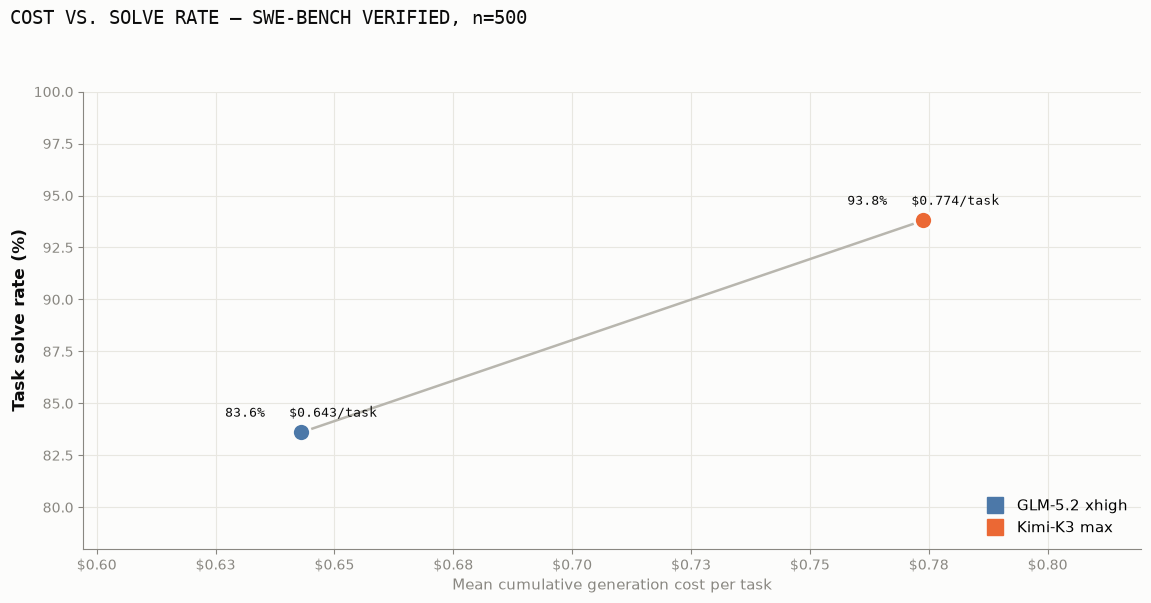

In [23]:
SURFACE = '#fcfcfb'; INK = '#0b0b0b'; MUTED = '#898781'; GRID = '#e8e7e1'; CONNECT = '#b8b6ae'
MONO = 'DejaVu Sans Mono'
pts = comparison.reset_index().sort_values('cost_per_task_usd')

fig, ax = plt.subplots(figsize=(11.6, 6.2))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.plot(pts.cost_per_task_usd, pts.solve_rate_pct, color=CONNECT, lw=1.8, zorder=2, solid_capstyle='round')
for _, p in pts.iterrows():
    ax.plot(p.cost_per_task_usd, p.solve_rate_pct, 'o', ms=13, color=p.color,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
    ax.annotate(f'{p.solve_rate_pct:.1f}%   ${p.cost_per_task_usd:.3f}/task',
                (p.cost_per_task_usd, p.solve_rate_pct), xytext=(0, 9),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9.5, color=INK, fontfamily=MONO, zorder=5)

# Data-driven limits: the two bundles sit at very different price points.
span = pts.cost_per_task_usd.max() - pts.cost_per_task_usd.min()
padding = max(0.04, 0.35 * span)
ax.set_xlim(pts.cost_per_task_usd.min() - padding, pts.cost_per_task_usd.max() + padding)
ax.set_ylim(78, 100)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:.2f}'))
ax.set_ylabel('Task solve rate (%)', fontsize=12, fontweight='bold', color=INK)
ax.set_xlabel('Mean cumulative generation cost per task', fontsize=10.5, color=MUTED)
ax.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right'): ax.spines[side].set_visible(False)
for side in ('left', 'bottom'): ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=10)
ax.legend(handles=[Line2D([], [], marker='s', ls='', ms=11, color=row.color, label=row.model)
                   for row in pts.itertuples()], loc='lower right', frameon=False,
          handletextpad=0.5, fontsize=10.5)
fig.suptitle('COST VS. SOLVE RATE — SWE-BENCH VERIFIED, n=500',
             x=0.012, y=0.975, ha='left', va='top', fontsize=13.5, fontfamily=MONO, color=INK)
fig.tight_layout(rect=[0, 0.01, 1, 0.93])
out = GRAPHS / 'fig8_swebench_verified_cost_vs_accuracy_n500.png'
fig.savefig(out, dpi=170, facecolor=SURFACE)
print(f'saved -> {out}')
plt.show()

## Paired GLM-5.2 vs. Kimi-K3 per-task costs

The same pricing as every other figure, now task by task rather than in aggregate, so the two models
can be compared on identical work. Per-task tokens are summed over every attempt.

The pairing uses the 499 tasks where both models have a trajectory, since GLM-5.2 is missing
`sphinx-doc__sphinx-7454`.

In [24]:
import numpy as np

BOOTSTRAP_SAMPLES = 100_000
BOOTSTRAP_SEED = 20260807

TOKEN_COLUMNS = ['prompt_tokens', 'cached_tokens', 'completion_tokens']


def task_tokens(frame):
    """Per-task token totals, summed across that task's attempts."""
    tokens = frame.groupby('instance_id')[TOKEN_COLUMNS].sum().sort_index()
    tokens['uncached_tokens'] = tokens.prompt_tokens - tokens.cached_tokens
    tokens['total_tokens'] = tokens.prompt_tokens + tokens.completion_tokens
    assert (tokens[['uncached_tokens', 'cached_tokens', 'completion_tokens']] >= 0).all().all()
    return tokens


def estimate_task_costs(tokens, rates):
    return token_cost(tokens.uncached_tokens, tokens.cached_tokens, tokens.completion_tokens, rates)


glm_tasks = task_tokens(swe_attempts['GLM-5.2 xhigh'])
kimi_tasks = task_tokens(swe_attempts['Kimi-K3 max'])
paired_index = glm_tasks.index.intersection(kimi_tasks.index)
missing = sorted(set(kimi_tasks.index) ^ set(glm_tasks.index))
print(f'Paired tasks: {len(paired_index)} of {SWE_TASKS}' + (f' · unpaired: {missing}' if missing else ''))
glm_tasks = glm_tasks.loc[paired_index]
kimi_tasks = kimi_tasks.loc[paired_index]

glm_task_cost = estimate_task_costs(glm_tasks, MODELS['GLM-5.2 xhigh']['rates'])
kimi_task_cost = estimate_task_costs(kimi_tasks, MODELS['Kimi-K3 max']['rates'])
paired_costs = pd.DataFrame({'GLM-5.2 estimated': glm_task_cost, 'Kimi-K3 estimated': kimi_task_cost})
paired_costs['Kimi minus GLM'] = paired_costs['Kimi-K3 estimated'] - paired_costs['GLM-5.2 estimated']
cost_summary = pd.DataFrame({
    'total estimated cost': paired_costs.iloc[:, :2].sum(),
    'mean estimated cost/task': paired_costs.iloc[:, :2].mean(),
})
display(cost_summary.map(lambda value: f'${value:,.3f}'))
paired_costs.head()

Paired tasks: 499 of 500 · unpaired: ['sphinx-doc__sphinx-7454']


,total estimated cost,mean estimated cost/task
GLM-5.2 estimated,$321.495,$0.644
Kimi-K3 estimated,$385.837,$0.773


,GLM-5.2 estimated,Kimi-K3 estimated,Kimi minus GLM
instance_id,,,
astropy__astropy-12907,0.108761,0.578134,0.469374
astropy__astropy-13033,0.270443,0.448603,0.178160
astropy__astropy-13236,0.960260,1.404345,0.444084
astropy__astropy-13398,2.356835,2.029904,-0.326931
astropy__astropy-13453,0.736336,0.674083,-0.062253


saved -> /Users/friendli/Documents/agent-benchmark/notebooks/tmp/graphs/glm_5_2_vs_kimi_k3_cost_confidence_intervals.png


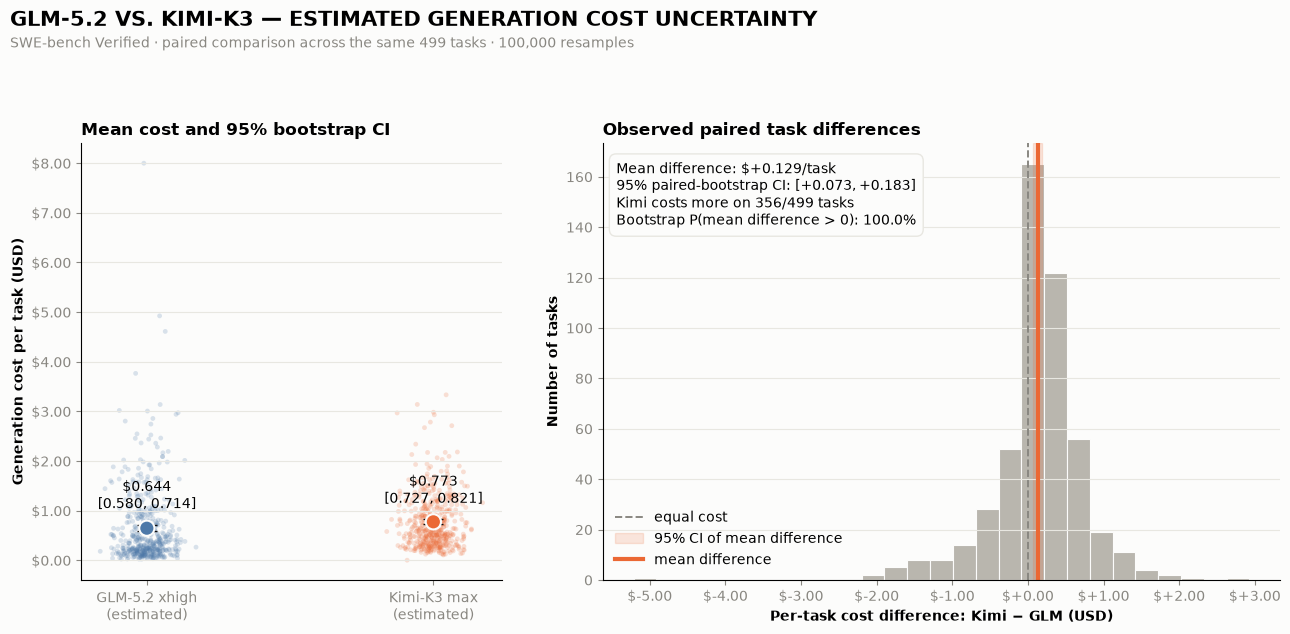

In [25]:
def paired_bootstrap_means(left, right, samples=BOOTSTRAP_SAMPLES, seed=BOOTSTRAP_SEED, chunk=10_000):
    rng = np.random.default_rng(seed)
    left_boot = np.empty(samples); right_boot = np.empty(samples)
    for start in range(0, samples, chunk):
        stop = min(start + chunk, samples)
        ix = rng.integers(0, len(left), size=(stop - start, len(left)))
        left_boot[start:stop] = left[ix].mean(axis=1)
        right_boot[start:stop] = right[ix].mean(axis=1)
    return left_boot, right_boot, right_boot - left_boot

glm_values = glm_task_cost.to_numpy(); kimi_values = kimi_task_cost.to_numpy()
glm_boot, kimi_boot, diff_boot = paired_bootstrap_means(glm_values, kimi_values)
ci = lambda values: tuple(np.quantile(values, [0.025, 0.975]))
glm_ci, kimi_ci, diff_ci = ci(glm_boot), ci(kimi_boot), ci(diff_boot)
diff = kimi_values - glm_values
rng = np.random.default_rng(BOOTSTRAP_SEED)

fig, (ax_mean, ax_diff) = plt.subplots(1, 2, figsize=(13.5, 6.8), gridspec_kw={'width_ratios': [0.9, 1.45]})
fig.patch.set_facecolor(SURFACE)
for ax in (ax_mean, ax_diff):
    ax.set_facecolor(SURFACE); ax.grid(axis='y', color=GRID, lw=0.8, zorder=0)
    ax.spines[['top', 'right']].set_visible(False); ax.tick_params(colors=MUTED)
jitter = rng.normal(0, 0.055, len(glm_values))
ax_mean.scatter(jitter, glm_values, s=12, alpha=.20, color='#4c78a8', edgecolors='none')
ax_mean.scatter(1 + jitter, kimi_values, s=12, alpha=.20, color='#eb6834', edgecolors='none')
means = np.array([glm_values.mean(), kimi_values.mean()]); cis = np.array([glm_ci, kimi_ci])
errors = np.vstack([means - cis[:, 0], cis[:, 1] - means])
ax_mean.errorbar([0, 1], means, yerr=errors, fmt='none', ecolor=INK, lw=2.2, capsize=7, zorder=4)
ax_mean.scatter([0, 1], means, s=120, color=['#4c78a8', '#eb6834'], edgecolor=SURFACE, lw=1.5, zorder=5)
for x, mean, bounds in zip([0, 1], means, [glm_ci, kimi_ci]):
    ax_mean.annotate(f'${mean:.3f}\n[{bounds[0]:.3f}, {bounds[1]:.3f}]', (x, bounds[1]), xytext=(0, 12), textcoords='offset points', ha='center')
ax_mean.set_xticks([0, 1], ['GLM-5.2 xhigh\n(estimated)', 'Kimi-K3 max\n(estimated)'])
ax_mean.set_ylabel('Generation cost per task (USD)', fontweight='bold'); ax_mean.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:.2f}'))
ax_mean.set_title('Mean cost and 95% bootstrap CI', loc='left', fontweight='bold')
ax_diff.hist(diff, bins=np.linspace(diff.min(), diff.max(), 28), color='#b9b6ae', edgecolor=SURFACE, lw=.8)
ax_diff.axvline(0, color=MUTED, lw=1.4, ls='--', label='equal cost')
ax_diff.axvspan(*diff_ci, color='#eb6834', alpha=.16, label='95% CI of mean difference')
ax_diff.axvline(diff.mean(), color='#eb6834', lw=3, label='mean difference')
ax_diff.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:+.2f}'))
ax_diff.set_xlabel('Per-task cost difference: Kimi − GLM (USD)', fontweight='bold'); ax_diff.set_ylabel('Number of tasks', fontweight='bold')
ax_diff.set_title('Observed paired task differences', loc='left', fontweight='bold'); ax_diff.legend(frameon=False)
ax_diff.text(.02, .96, f'Mean difference: ${diff.mean():+.3f}/task\n95% paired-bootstrap CI: [${diff_ci[0]:+.3f}, ${diff_ci[1]:+.3f}]\nKimi costs more on {(diff > 0).sum()}/{len(diff)} tasks\nBootstrap P(mean difference > 0): {(diff_boot > 0).mean():.1%}', transform=ax_diff.transAxes, va='top', bbox={'boxstyle': 'round,pad=.5', 'facecolor': SURFACE, 'edgecolor': GRID})
fig.suptitle('GLM-5.2 VS. KIMI-K3 — ESTIMATED GENERATION COST UNCERTAINTY', x=.035, y=.98, ha='left', fontsize=15, fontweight='bold')
fig.text(.035, .925, f'SWE-bench Verified · paired comparison across the same {len(diff)} tasks · {BOOTSTRAP_SAMPLES:,} resamples', color=MUTED)
fig.tight_layout(rect=[.025, .055, .99, .89], w_pad=3.2)
cost_ci_out = GRAPHS / 'glm_5_2_vs_kimi_k3_cost_confidence_intervals.png'
cost_ci_out.parent.mkdir(parents=True, exist_ok=True); fig.savefig(cost_ci_out, dpi=200, facecolor=SURFACE)
print(f'saved -> {cost_ci_out}'); plt.show()

saved -> /Users/friendli/Documents/agent-benchmark/notebooks/tmp/graphs/glm_5_2_vs_kimi_k3_token_distributions.png


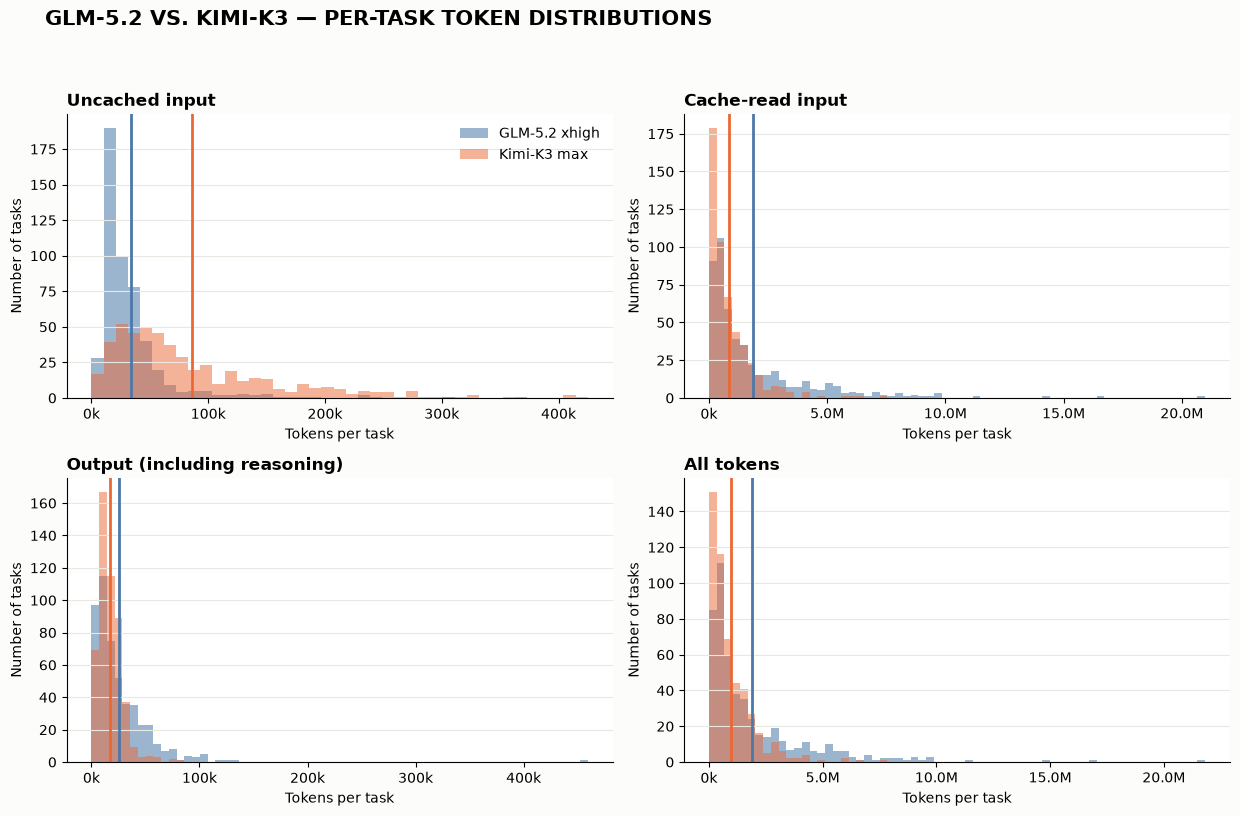

In [26]:
token_panels = [('uncached_tokens', 'Uncached input'), ('cached_tokens', 'Cache-read input'), ('completion_tokens', 'Output (including reasoning)'), ('total_tokens', 'All tokens')]
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2))
fig.patch.set_facecolor(SURFACE)
for ax, (column, title) in zip(axes.flat, token_panels):
    combined = np.r_[glm_tasks[column], kimi_tasks[column]]
    bins = np.histogram_bin_edges(combined, bins='auto')
    ax.hist(glm_tasks[column], bins=bins, alpha=.55, color='#4c78a8', label='GLM-5.2 xhigh')
    ax.hist(kimi_tasks[column], bins=bins, alpha=.50, color='#eb6834', label='Kimi-K3 max')
    ax.axvline(glm_tasks[column].mean(), color='#4c78a8', lw=2)
    ax.axvline(kimi_tasks[column].mean(), color='#eb6834', lw=2)
    ax.set_title(title, loc='left', fontweight='bold'); ax.set_xlabel('Tokens per task'); ax.set_ylabel('Number of tasks')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v/1_000_000:.1f}M' if abs(v) >= 1_000_000 else f'{v/1_000:.0f}k'))
    ax.grid(axis='y', color=GRID, lw=.8); ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].legend(frameon=False)
fig.suptitle('GLM-5.2 VS. KIMI-K3 — PER-TASK TOKEN DISTRIBUTIONS', x=.04, y=.99, ha='left', fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, .95])
token_out = GRAPHS / 'glm_5_2_vs_kimi_k3_token_distributions.png'
fig.savefig(token_out, dpi=200, facecolor=SURFACE)
print(f'saved -> {token_out}'); plt.show()

## Terminal-Bench 2.1: load results and price both models

The aggregated 89-task bundle carries one selected verdict per task in `task_results.jsonl` and every
initial and retry attempt in `attempts.jsonl`, each with its input, cached, and output token counts.
The benchmark summary stays the source of truth for the 89-task denominator and the resolved count.

Both models are priced from those token counts, the same way as on SWE-bench. Note that the bundle's
own `estimated_cost_usd` column is a real token-price estimate for GLM-5.2 but is just a copy of the
recorded `cost_usd` for Kimi-K3, so it cannot serve as the shared baseline; the GLM-5.2 reconstruction
is checked against it below.

As on SWE-bench, retries count: GLM-5.2 spent 101 attempts and Kimi-K3 122 to cover the 89 tasks.

In [27]:
def load_terminal(label):
    """Attempt-level rows plus the run summary for one Terminal-Bench model."""
    directory = TB / MODELS[label]['tb']
    summary = json.loads((directory / 'summary.json').read_text())
    lines = (directory / 'attempts.jsonl').read_text().splitlines()
    attempts = pd.DataFrame([json.loads(line) for line in lines if line.strip()])
    tasks = pd.DataFrame([json.loads(line) for line in
                          (directory / 'task_results.jsonl').read_text().splitlines() if line.strip()])
    assert summary['task_count'] == TB_TASKS == len(tasks)
    assert len(attempts) == summary['attempt_count']
    assert tasks.resolved.sum() == summary['resolved_count']
    # input_tokens includes cached input, matching the SWE-bench convention.
    assert (attempts.cached_tokens <= attempts.input_tokens).all()
    return summary, attempts, tasks


terminal_loaded = {label: load_terminal(label) for label in MODELS}
tb_attempts = {label: item[1] for label, item in terminal_loaded.items()}
terminal_usage = pd.DataFrame({
    label: {
        'tasks': summary['task_count'],
        'attempts': len(attempts),
        'retries': summary['retry_count'],
        'input_tokens': int(attempts.input_tokens.sum()),
        'cached_tokens': int(attempts.cached_tokens.sum()),
        'uncached_tokens': int((attempts.input_tokens - attempts.cached_tokens).sum()),
        'completion_tokens': int(attempts.output_tokens.sum()),
        'estimated_cost_usd': float(attempts.estimated_cost_usd.fillna(0).sum()),
        'recorded_cost_usd': float(attempts.cost_usd.fillna(0).sum()),
        'cost_records': int(attempts.cost_usd.notna().sum()),
        'cost_method': summary['cost_method'],
    }
    for label, (summary, attempts, _) in terminal_loaded.items()
}).T
terminal_usage

,tasks,attempts,retries,input_tokens,cached_tokens,uncached_tokens,completion_tokens,estimated_cost_usd,recorded_cost_usd,cost_records,cost_method
GLM-5.2 xhigh,89,101,12,165142898,131109568,34033330,5507607,105.96862,0.139772,5,token-price estimate
Kimi-K3 max,89,122,33,58457842,51593841,6864001,2385096,71.345229,71.345229,116,recorded cost


In [28]:
tb_cost_components = pd.DataFrame({
    label: {
        'uncached input': token_cost(row.uncached_tokens, 0, 0, MODELS[label]['rates']),
        'cached input': token_cost(0, row.cached_tokens, 0, MODELS[label]['rates']),
        'output (includes reasoning)': token_cost(0, 0, row.completion_tokens, MODELS[label]['rates']),
    }
    for label, row in terminal_usage.iterrows()
})
tb_cost_components.loc['total'] = tb_cost_components.sum()
tb_estimated_cost = tb_cost_components.loc['total'].to_dict()
display(tb_cost_components.style.format('${:,.2f}'))
for label, cost in tb_estimated_cost.items():
    print(f'{label}: estimated ${cost:,.2f} total -> ${cost / TB_TASKS:,.3f}/task')

# The bundle's estimated_cost_usd is a genuine token-price estimate for GLM-5.2 only.
bundle_estimate = float(terminal_usage.loc['GLM-5.2 xhigh', 'estimated_cost_usd'])
print(f"\nGLM-5.2 bundle estimated_cost_usd: ${bundle_estimate:,.2f} (reconstruction must match)")
assert abs(tb_estimated_cost['GLM-5.2 xhigh'] - bundle_estimate) < 0.01

,GLM-5.2 xhigh,Kimi-K3 max
uncached input,$47.65,$20.59
cached input,$34.09,$15.48
output (includes reasoning),$24.23,$35.78
total,$105.97,$71.85


GLM-5.2 xhigh: estimated $105.97 total -> $1.191/task
Kimi-K3 max: estimated $71.85 total -> $0.807/task

GLM-5.2 bundle estimated_cost_usd: $105.97 (reconstruction must match)


In [29]:
terminal_rows = []
for label, cfg in MODELS.items():
    summary, attempts, _ = terminal_loaded[label]
    tasks = summary['task_count']
    resolved = summary['resolved_count']
    cost = tb_estimated_cost[label]
    terminal_rows.append({
        'model': label, 'resolved': resolved, 'tasks': tasks,
        'solve_rate_pct': 100 * resolved / tasks, 'total_cost_usd': cost,
        'cost_per_task_usd': cost / tasks, 'cost_per_resolved_usd': cost / resolved,
        'cost_basis': 'tokens at published rates', 'color': cfg['color'],
    })
terminal_comparison = pd.DataFrame(terminal_rows).set_index('model')
display(terminal_comparison.drop(columns='color').style.format({
    'solve_rate_pct': '{:.1f}%', 'total_cost_usd': '${:,.2f}',
    'cost_per_task_usd': '${:.3f}', 'cost_per_resolved_usd': '${:.2f}',
}))

,resolved,tasks,solve_rate_pct,total_cost_usd,cost_per_task_usd,cost_per_resolved_usd,cost_basis
model,,,,,,,
GLM-5.2 xhigh,64,89,71.9%,$105.97,$1.191,$1.66,tokens at published rates
Kimi-K3 max,72,89,80.9%,$71.85,$0.807,$1.00,tokens at published rates


## Terminal-Bench 2.1 cost vs. solve rate

Cost per task uses all 89 benchmark tasks, including the ones that errored, matching the accuracy
denominator in the run summaries.

saved -> /Users/friendli/Documents/agent-benchmark/notebooks/tmp/graphs/fig8_terminal_bench_2_1_cost_vs_accuracy_n89.png


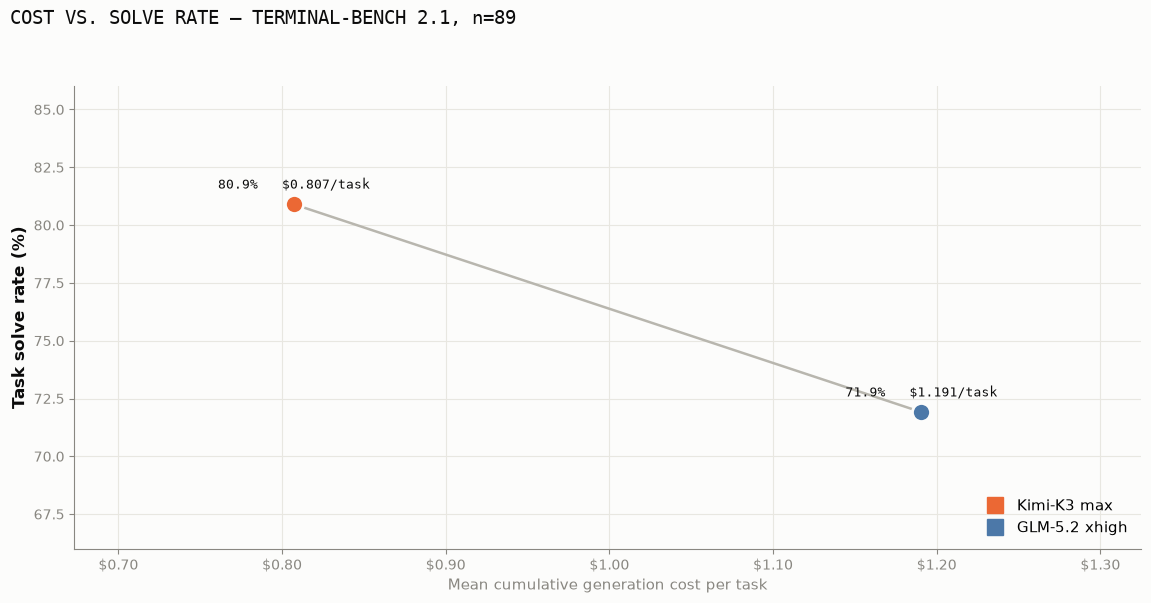

In [30]:
SURFACE = '#fcfcfb'; INK = '#0b0b0b'; MUTED = '#898781'; GRID = '#e8e7e1'; CONNECT = '#b8b6ae'
MONO = 'DejaVu Sans Mono'
pts = terminal_comparison.reset_index().sort_values('cost_per_task_usd')

fig, ax = plt.subplots(figsize=(11.6, 6.2))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.plot(pts.cost_per_task_usd, pts.solve_rate_pct, color=CONNECT, lw=1.8, zorder=2, solid_capstyle='round')
for _, p in pts.iterrows():
    ax.plot(p.cost_per_task_usd, p.solve_rate_pct, 'o', ms=13, color=p.color,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
    ax.annotate(f'{p.solve_rate_pct:.1f}%   ${p.cost_per_task_usd:.3f}/task',
                (p.cost_per_task_usd, p.solve_rate_pct), xytext=(0, 9),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9.5, color=INK, fontfamily=MONO, zorder=5)

# Data-driven limits: the two bundles sit at very different price points.
span = pts.cost_per_task_usd.max() - pts.cost_per_task_usd.min()
padding = max(0.04, 0.35 * span)
ax.set_xlim(pts.cost_per_task_usd.min() - padding, pts.cost_per_task_usd.max() + padding)
ax.set_ylim(66, 86)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:.2f}'))
ax.set_ylabel('Task solve rate (%)', fontsize=12, fontweight='bold', color=INK)
ax.set_xlabel('Mean cumulative generation cost per task', fontsize=10.5, color=MUTED)
ax.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right'): ax.spines[side].set_visible(False)
for side in ('left', 'bottom'): ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=10)
ax.legend(handles=[Line2D([], [], marker='s', ls='', ms=11, color=row.color, label=row.model)
                   for row in pts.itertuples()], loc='lower right', frameon=False,
          handletextpad=0.5, fontsize=10.5)
fig.suptitle('COST VS. SOLVE RATE — TERMINAL-BENCH 2.1, n=89',
             x=0.012, y=0.975, ha='left', va='top', fontsize=13.5, fontfamily=MONO, color=INK)
fig.tight_layout(rect=[0, 0.01, 1, 0.93])
out = GRAPHS / 'fig8_terminal_bench_2_1_cost_vs_accuracy_n89.png'
fig.savefig(out, dpi=170, facecolor=SURFACE)
print(f'saved -> {out}')
plt.show()

## Actual recorded cost in the logs

What the runs actually recorded, with no estimation. This is the audit trail for the baseline choice
above, and it is not used by any figure.

`coverage_pct` is the share of attempts carrying a cost value. Where coverage is partial the recorded
total is a floor, not a total: GLM-5.2's few dollars cover a handful of attempts out of hundreds.
Kimi-K3 is nearly complete, so `estimated_vs_recorded_pct` shows how closely the token estimate
tracks a real bill — the check that justifies applying the same estimate to GLM-5.2.

In [31]:
actual_rows = []
for label in MODELS:
    swe_frame = swe_attempts[label]
    _, tb_frame, _ = terminal_loaded[label]
    for benchmark, attempts, recorded, tasks, estimated in (
        ('SWE-bench Verified', len(swe_frame), swe_frame.recorded_cost_usd,
         SWE_TASKS, swe_estimated_cost[label]),
        ('Terminal-Bench 2.1', len(tb_frame), tb_frame.cost_usd,
         TB_TASKS, tb_estimated_cost[label]),
    ):
        total = float(recorded.fillna(0).sum())
        with_cost = int(recorded.notna().sum())
        coverage = 100 * with_cost / attempts
        actual_rows.append({
            'benchmark': benchmark, 'model': label,
            'attempts': attempts, 'attempts_with_cost': with_cost,
            'coverage_pct': coverage,
            'recorded_cost_usd': total,
            'recorded_per_task_usd': total / tasks,
            'estimated_cost_usd': estimated,
            # Only meaningful where the log is a near-complete bill; a 10%-covered total is a floor,
            # so the ratio against it would say more about coverage than about pricing accuracy.
            'estimated_vs_recorded_pct': (100 * (estimated - total) / total) if coverage >= 90 else float('nan'),
        })
actual_cost = pd.DataFrame(actual_rows).sort_values(['benchmark', 'model']).set_index(['benchmark', 'model'])
display(actual_cost.style.format({
    'coverage_pct': '{:.1f}%', 'recorded_cost_usd': '${:,.2f}',
    'recorded_per_task_usd': '${:.3f}', 'estimated_cost_usd': '${:,.2f}',
    'estimated_vs_recorded_pct': '{:+.2f}%',
}, na_rep='— (partial log)'))

## Combined view: both benchmarks in one pane

Color identifies the model; marker shape and line style identify the benchmark. The two benchmarks
run in opposite directions — on SWE-bench the more accurate model costs more per task, on
Terminal-Bench it costs less.

saved -> /Users/friendli/Documents/agent-benchmark/notebooks/tmp/graphs/fig8_combined_cost_vs_accuracy_glm_5_2_vs_kimi_k3.png


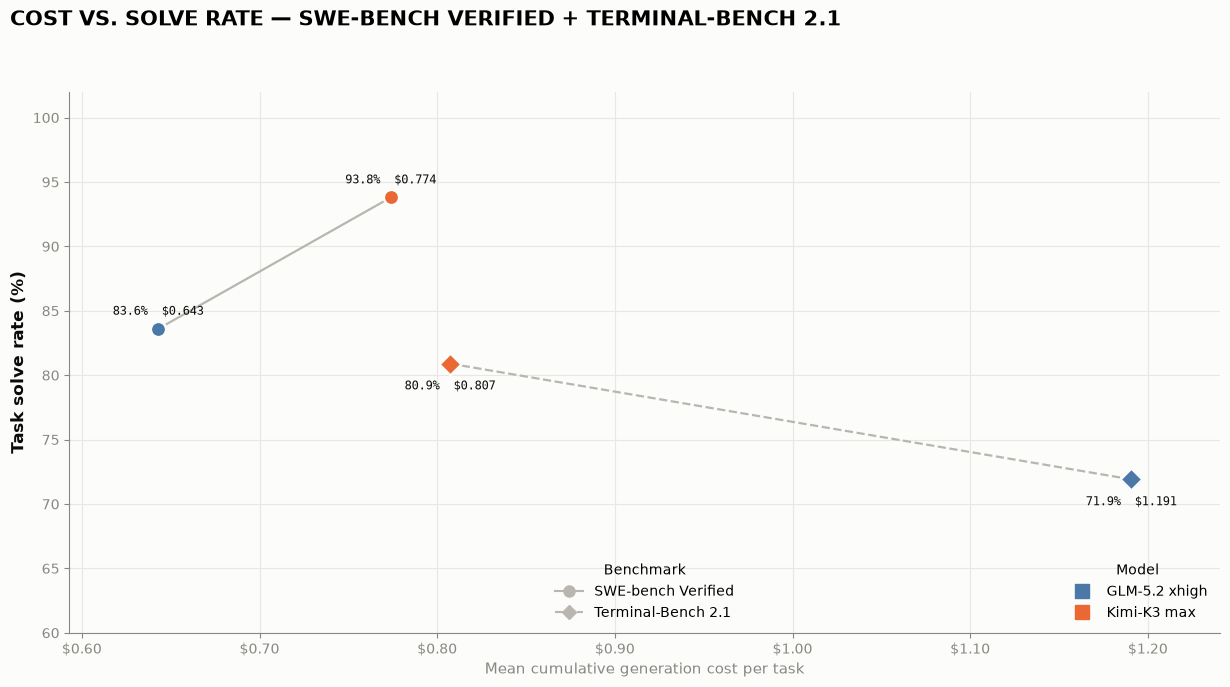

In [32]:
combined_sets = [
    ('SWE-bench Verified', comparison.reset_index(), 'o', '-'),
    ('Terminal-Bench 2.1', terminal_comparison.reset_index(), 'D', '--'),
]
fig, ax = plt.subplots(figsize=(12.4, 7.0))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
for benchmark, frame, marker, linestyle in combined_sets:
    frame = frame.sort_values('cost_per_task_usd')
    ax.plot(frame.cost_per_task_usd, frame.solve_rate_pct, linestyle,
            color=CONNECT, lw=1.6, zorder=2)
    for _, p in frame.iterrows():
        ax.plot(p.cost_per_task_usd, p.solve_rate_pct, marker, ms=11, color=p.color,
                markeredgecolor=SURFACE, markeredgewidth=1.8, zorder=4)
        dy = 8 if benchmark == 'SWE-bench Verified' else -12
        va = 'bottom' if dy > 0 else 'top'
        ax.annotate(f'{p.solve_rate_pct:.1f}%  ${p.cost_per_task_usd:.3f}',
                    (p.cost_per_task_usd, p.solve_rate_pct), xytext=(0, dy),
                    textcoords='offset points', ha='center', va=va,
                    fontsize=8.7, color=INK, fontfamily=MONO)
all_costs = pd.concat([frame.cost_per_task_usd for _, frame, _, _ in combined_sets])
cost_padding = max(0.05, 0.08 * (all_costs.max() - all_costs.min()))
ax.set_xlim(all_costs.min() - cost_padding, all_costs.max() + cost_padding); ax.set_ylim(60, 102)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:.2f}'))
ax.set_ylabel('Task solve rate (%)', fontsize=12, fontweight='bold', color=INK)
ax.set_xlabel('Mean cumulative generation cost per task', fontsize=10.5, color=MUTED)
ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for side in ('top', 'right'): ax.spines[side].set_visible(False)
for side in ('left', 'bottom'): ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=10)
model_handles = [Line2D([], [], marker='s', ls='', ms=10, color=MODELS[label]['color'], label=label)
                 for label in MODELS]
benchmark_handles = [
    Line2D([], [], marker='o', ls='-', color=CONNECT, ms=8, label='SWE-bench Verified'),
    Line2D([], [], marker='D', ls='--', color=CONNECT, ms=7, label='Terminal-Bench 2.1'),
]
legend_models = ax.legend(handles=model_handles, title='Model', loc='lower right', frameon=False)
ax.add_artist(legend_models)
ax.legend(handles=benchmark_handles, title='Benchmark', loc='lower center', frameon=False)
fig.suptitle('COST VS. SOLVE RATE — SWE-BENCH VERIFIED + TERMINAL-BENCH 2.1',
             x=0.012, y=0.975, ha='left', va='top', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
out = GRAPHS / 'fig8_combined_cost_vs_accuracy_glm_5_2_vs_kimi_k3.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'saved -> {out}')
plt.show()

## Adding the router

A per-task router picks between the two models: whichever solved the task, and when both solved it,
whichever was cheaper. The selections come from
`notebooks/tmp/graphs/fig7_routing_glm_5_2_vs_kimi_k3_tasks.csv`, computed separately — this cell
reads `selected_model` and `routing_solved` from it and prices the choice.

Two things in that CSV are deliberately not used. Its cost columns cover only the selected attempt,
and they mix bases the same way the notebook used to, so pricing the router from them would not be
comparable to the model points. Instead the per-task tables below are rebuilt with `token_cost` from
the same all-attempts token counts behind every figure above, then asserted against the totals in
`comparison` and `terminal_comparison`.

Its `selected_model` column *is* used as given. The router's solve rate does not depend on cost —
solved-first is decided by the verdicts — but its cost tie-breaks were decided on the old mixed
basis, so a handful would flip if it re-decided on this one. The cell prints how many.

The router beats both models on both benchmarks while costing less than either, because the cheaper
model is often the one that solved the task.

SWE-bench Verified: 435 cost tie-breaks, 5 would flip on the token baseline
Terminal-Bench 2.1: 71 cost tie-breaks, 5 would flip on the token baseline


,model,resolved,tasks,solve_rate_pct,total_cost_usd,cost_per_task_usd,routed_to_glm,routed_to_kimi
benchmark,,,,,,,,
SWE-bench Verified,Routing,476,500,95.2%,$271.10,$0.542,329,171
Terminal-Bench 2.1,Routing,77,89,86.5%,$57.49,$0.646,46,43


saved -> /Users/friendli/Documents/agent-benchmark/notebooks/tmp/graphs/fig8_combined_cost_vs_accuracy_glm_5_2_vs_kimi_k3_with_routing.png


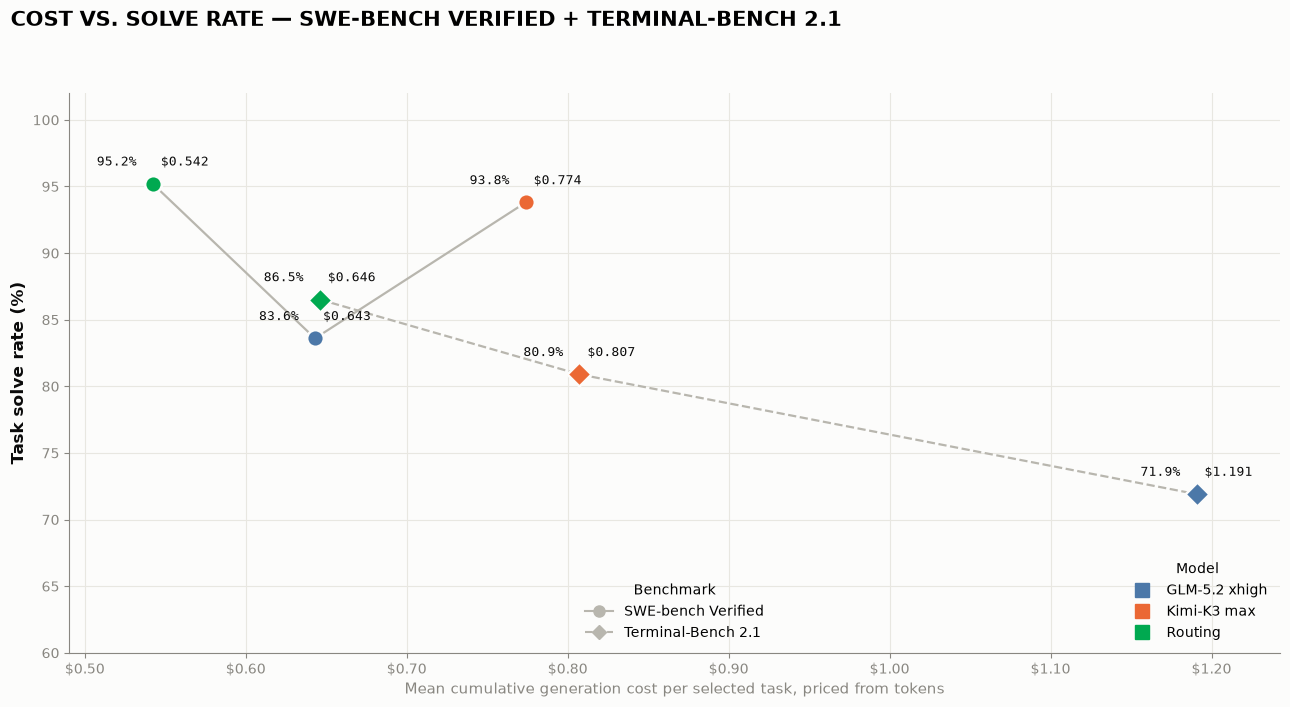

In [33]:
routing_tasks = pd.read_csv(ROUTING_TASKS)
FAMILY_TASKS = {'SWE-bench Verified': SWE_TASKS, 'Terminal-Bench 2.1': TB_TASKS}
assert set(routing_tasks.family) == set(FAMILY_TASKS)
ROUTING_KEY_TO_MODEL = {cfg['routing_key']: label for label, cfg in MODELS.items()}


def swe_task_costs(label):
    """Cumulative per-task SWE-bench cost, on the same basis as the `comparison` table."""
    return estimate_task_costs(task_tokens(swe_attempts[label]), MODELS[label]['rates'])


def tb_task_costs(label):
    """Cumulative per-task Terminal-Bench cost, on the same basis as `terminal_comparison`."""
    grouped = tb_attempts[label].groupby('task_id')[['input_tokens', 'cached_tokens', 'output_tokens']].sum()
    return token_cost(grouped.input_tokens - grouped.cached_tokens, grouped.cached_tokens,
                      grouped.output_tokens, MODELS[label]['rates'])


family_costs = {
    'SWE-bench Verified': {label: swe_task_costs(label) for label in MODELS},
    'Terminal-Bench 2.1': {label: tb_task_costs(label) for label in MODELS},
}
reference = {'SWE-bench Verified': comparison, 'Terminal-Bench 2.1': terminal_comparison}
for family, costs in family_costs.items():
    for label, series in costs.items():
        expected = float(reference[family].loc[label, 'total_cost_usd'])
        assert abs(float(series.sum()) - expected) < 0.01, (family, label, series.sum(), expected)

routing_rows = []
for family, group in routing_tasks.groupby('family'):
    tasks = FAMILY_TASKS[family]
    costs = family_costs[family]
    assert len(group) == tasks and group.task_id.is_unique
    selected = sum(costs[ROUTING_KEY_TO_MODEL[row.selected_model]][row.task_id] for row in group.itertuples())
    # How many cost tie-breaks the router would decide differently on this baseline.
    ties = group[group.selection_reason.isin(['cheaper', 'cheaper_or_equal'])]
    flipped = sum(
        (costs['GLM-5.2 xhigh'][row.task_id] <= costs['Kimi-K3 max'][row.task_id]) != (row.selected_model == 'GLM-5.2')
        for row in ties.itertuples())
    print(f'{family}: {len(ties)} cost tie-breaks, {flipped} would flip on the token baseline')
    routing_rows.append({
        'benchmark': family, 'model': ROUTING['label'],
        'resolved': int(group.routing_solved.sum()), 'tasks': tasks,
        'solve_rate_pct': 100 * group.routing_solved.mean(),
        'total_cost_usd': selected, 'cost_per_task_usd': selected / tasks,
        'routed_to_glm': int((group.selected_model == 'GLM-5.2').sum()),
        'routed_to_kimi': int((group.selected_model == 'Kimi-K3').sum()),
        'color': ROUTING['color'],
    })
routing = pd.DataFrame(routing_rows).set_index('benchmark')
display(routing.drop(columns='color').style.format({
    'solve_rate_pct': '{:.1f}%', 'total_cost_usd': '${:,.2f}', 'cost_per_task_usd': '${:.3f}',
}))

routed_sets = [
    ('SWE-bench Verified', comparison.reset_index(), 'o', '-'),
    ('Terminal-Bench 2.1', terminal_comparison.reset_index(), 'D', '--'),
]
fig, ax = plt.subplots(figsize=(13.0, 7.2))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
for benchmark, frame, marker, linestyle in routed_sets:
    frame = pd.concat([frame, routing.loc[[benchmark]].reset_index(drop=True)], ignore_index=True)
    frame = frame.sort_values('cost_per_task_usd')
    ax.plot(frame.cost_per_task_usd, frame.solve_rate_pct, linestyle,
            color=CONNECT, lw=1.6, zorder=2)
    for _, p in frame.iterrows():
        ax.plot(p.cost_per_task_usd, p.solve_rate_pct, marker, ms=12, color=p.color,
                markeredgecolor=SURFACE, markeredgewidth=1.8, zorder=4)
        ax.annotate(f'{p.solve_rate_pct:.1f}%   ${p.cost_per_task_usd:.3f}',
                    (p.cost_per_task_usd, p.solve_rate_pct), xytext=(0, 11),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=9, color=INK, fontfamily=MONO, zorder=5)

routed_costs = pd.concat([
    comparison.cost_per_task_usd, terminal_comparison.cost_per_task_usd, routing.cost_per_task_usd])
padding = max(0.05, 0.08 * (routed_costs.max() - routed_costs.min()))
ax.set_xlim(routed_costs.min() - padding, routed_costs.max() + padding); ax.set_ylim(60, 102)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:.2f}'))
ax.set_ylabel('Task solve rate (%)', fontsize=12, fontweight='bold', color=INK)
ax.set_xlabel('Mean cumulative generation cost per selected task, priced from tokens',
              fontsize=10.5, color=MUTED)
ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for side in ('top', 'right'): ax.spines[side].set_visible(False)
for side in ('left', 'bottom'): ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=10)
model_handles = [Line2D([], [], marker='s', ls='', ms=10, color=MODELS[label]['color'], label=label)
                 for label in MODELS]
model_handles.append(Line2D([], [], marker='s', ls='', ms=10, color=ROUTING['color'], label=ROUTING['label']))
benchmark_handles = [
    Line2D([], [], marker='o', ls='-', color=CONNECT, ms=8, label='SWE-bench Verified'),
    Line2D([], [], marker='D', ls='--', color=CONNECT, ms=7, label='Terminal-Bench 2.1'),
]
legend_models = ax.legend(handles=model_handles, title='Model', loc='lower right', frameon=False)
ax.add_artist(legend_models)
ax.legend(handles=benchmark_handles, title='Benchmark', loc='lower center', frameon=False)
fig.suptitle('COST VS. SOLVE RATE — SWE-BENCH VERIFIED + TERMINAL-BENCH 2.1',
             x=0.012, y=0.975, ha='left', va='top', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
out = GRAPHS / 'fig8_combined_cost_vs_accuracy_glm_5_2_vs_kimi_k3_with_routing.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'saved -> {out}')
plt.show()